<a href="https://colab.research.google.com/github/kthing1/DATA110-FALL2025/blob/data110-fall2025/Week7_KTHING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the penguins dataset from seaborn
penguins = sns.load_dataset('penguins')

# Display the first few rows of the dataset
print(penguins.head())


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [3]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
penguins.describe()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
plt.scatter(penguins['bill_length_mm'], penguins['bill_depth_mm'])
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.title('Bill Length vs. Bill Depth')
plt.show()

In [ ]:
# Set figure size
plt.figure(figsize=(8, 5))

# Scatter plot (manually colored)
plt.scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"], color="dodgerblue", alpha=0.6, edgecolors="black", label="Data Points")

# Regression line
sns.regplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", scatter=False, color="red", ci=None, label="Regression Line")

# Labels and title
plt.xlabel("Bill Length (mm)", fontsize=12)
plt.ylabel("Bill Depth (mm)", fontsize=12)
plt.title("Penguin Bill Measurements with Regression", fontsize=14)

# Add legend
plt.legend()

# Show plot
plt.show()

In [ ]:
#Task 1: Create a Similar Plot for Bill Length vs. Flipper Length

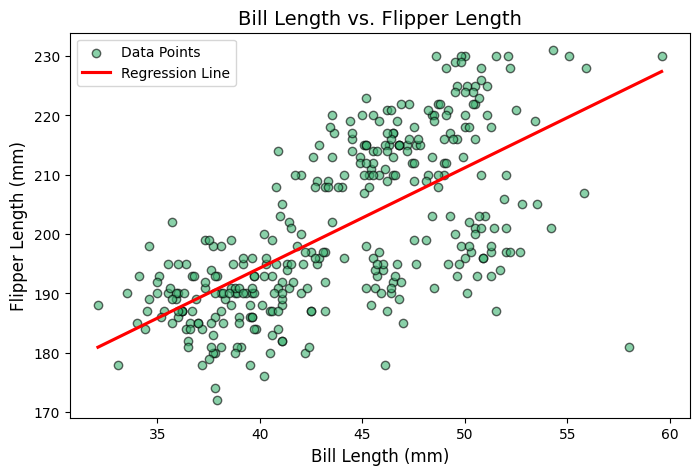

In [6]:
penguins = sns.load_dataset('penguins')

# --- Task 1: Bill Length vs. Flipper Length ---
plt.figure(figsize=(8, 5))

plt.scatter(penguins["bill_length_mm"], penguins["flipper_length_mm"],
            color="mediumseagreen", alpha=0.6, edgecolors="black", label="Data Points")

sns.regplot(data=penguins, x="bill_length_mm", y="flipper_length_mm",
            scatter=False, color="red", ci=None, label="Regression Line")

plt.xlabel("Bill Length (mm)", fontsize=12)
plt.ylabel("Flipper Length (mm)", fontsize=12)
plt.title("Bill Length vs. Flipper Length", fontsize=14)
plt.legend()
plt.show()

In [ ]:
# Task 2: Create a Similar Plot for Bill Length vs. Body Mass

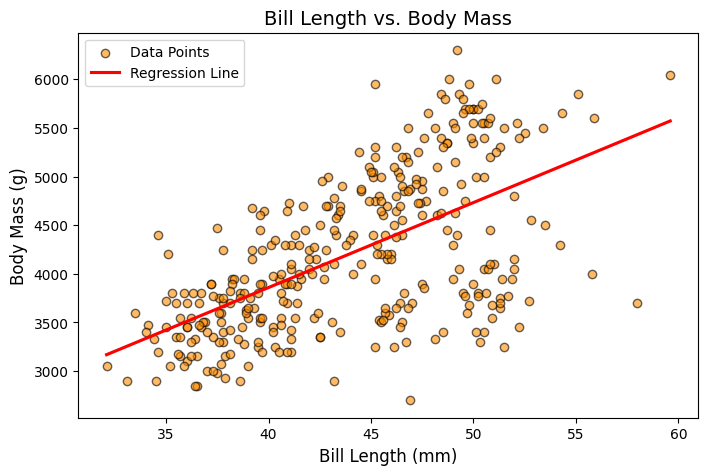

In [7]:
# --- Task 2: Bill Length vs. Body Mass ---
plt.figure(figsize=(8, 5))

plt.scatter(penguins["bill_length_mm"], penguins["body_mass_g"],
            color="darkorange", alpha=0.6, edgecolors="black", label="Data Points")

sns.regplot(data=penguins, x="bill_length_mm", y="body_mass_g",
            scatter=False, color="red", ci=None, label="Regression Line")

plt.xlabel("Bill Length (mm)", fontsize=12)
plt.ylabel("Body Mass (g)", fontsize=12)
plt.title("Bill Length vs. Body Mass", fontsize=14)
plt.legend()
plt.show()

# Data Wrangling

### 1. Filter Data by Species
To analyze a specific species, we can filter the dataset. Below, we extract only **Adelie** penguins and check the unique species available in the dataset.


In [ ]:
penguins_adeile=penguins[penguins['species']=='Adelie']
penguins['species'].unique()

In [ ]:
# Task 3: Make 3 subplots — scatter + regression — for each species separately


In [ ]:
# Check for missing values
print(penguins.isnull().sum())


In [ ]:
# Filter penguins by species and select bill_length_mm for Adelie
adelie_bill_length = penguins[penguins['species'] == 'Adelie']['bill_length_mm']

# Display the result
print(adelie_bill_length)

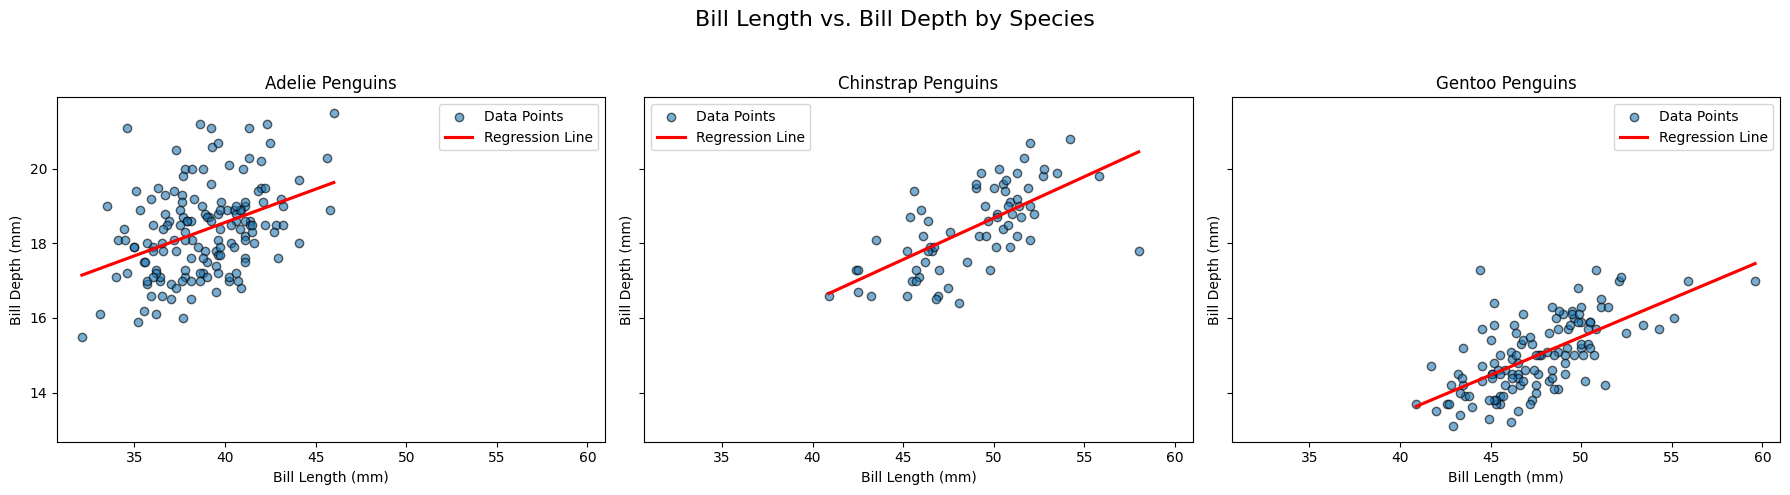

In [8]:
# --- Task 3: Make 3 subplots — scatter + regression — for each species separately ---
penguins = sns.load_dataset('penguins')

species_list = penguins['species'].dropna().unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for i, species in enumerate(species_list):
    ax = axes[i]
    subset = penguins[penguins['species'] == species]

    ax.scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
               alpha=0.6, edgecolors='black', label='Data Points')

    sns.regplot(data=subset, x='bill_length_mm', y='bill_depth_mm',
                scatter=False, color='red', ci=None, ax=ax, label='Regression Line')

    ax.set_xlabel('Bill Length (mm)')
    ax.set_ylabel('Bill Depth (mm)')
    ax.set_title(f'{species} Penguins')
    ax.legend()

plt.suptitle('Bill Length vs. Bill Depth by Species', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Seaborn Pairplot: Visualizing Relationships in the Penguins Dataset

##  What is `sns.pairplot()`?
One of the **most useful commands** in Seaborn is `pairplot()`, which **creates a scatterplot matrix** for all **numerical variables** in a dataset. This helps to **visualize relationships** between different features.




In [ ]:
# Pairplot will create all scatter plots for the numerical columns
sns.pairplot(penguins)

In [ ]:
# Pairplot excluding non-numerical columns and using a hue for species
sns.pairplot(penguins, hue="species", diag_kind="kde")

plt.show()


In [ ]:
# Pairplot excluding non-numerical columns and using a hue for species
sns.pairplot(penguins, hue="island", diag_kind="kde")

plt.show()


In [ ]:
# Pairplot excluding non-numerical columns and using a hue for species
sns.pairplot(penguins, hue="species", markers=["o", "s", "D"])


plt.show()

In [ ]:
sns.pairplot(penguins, hue="species", height=3.5)


In [ ]:
sns.pairplot(penguins, hue="species", palette="coolwarm")


# Task 4: Pairplot Remix

Make a **new pairplot** for the penguins dataset with these settings:

- Use a **different column** for `hue` than before (for example, `island` or `sex`).  
- Choose **different markers** such as `["o", "s", "D"]`.  
- Pick a **different color palette** (for example, `"magma"` or `"coolwarm"`).  
- Keep the **diagonal as KDE** (`diag_kind="kde"`).   
- Drop missing values for the columns you use.  




### Key Features of `sns.pairplot`:

1. **Plots All Pairwise Relationships**:
   - For a dataset with `n` numerical columns, `pairplot` creates an $ n \times n $ grid of subplots.
   - Each off-diagonal plot is a scatter plot showing the relationship between two numerical variables.
   - For $ n $ columns, there are $\binom{n}{2}$ scatter plots and $n$ diagonal plots.

2. **Diagonal Plots (Histograms or KDEs)**:
   - By default, `pairplot` plots histograms for the diagonal cells to show the distribution of each numerical variable.
   - You can change this to kernel density estimation (KDE) using the `diag_kind` argument.

3. **Hue (Color Coding by Category)**:
   - Use the `hue` parameter to color-code the scatter plots by a categorical variable (like species, sex or Island).
   - This allows you to see how different categories are distributed across pairs of numerical variables.

4. **Customization**:
   - You can customize marker styles, palettes, plot size, and other visual aspects of the grid.
   



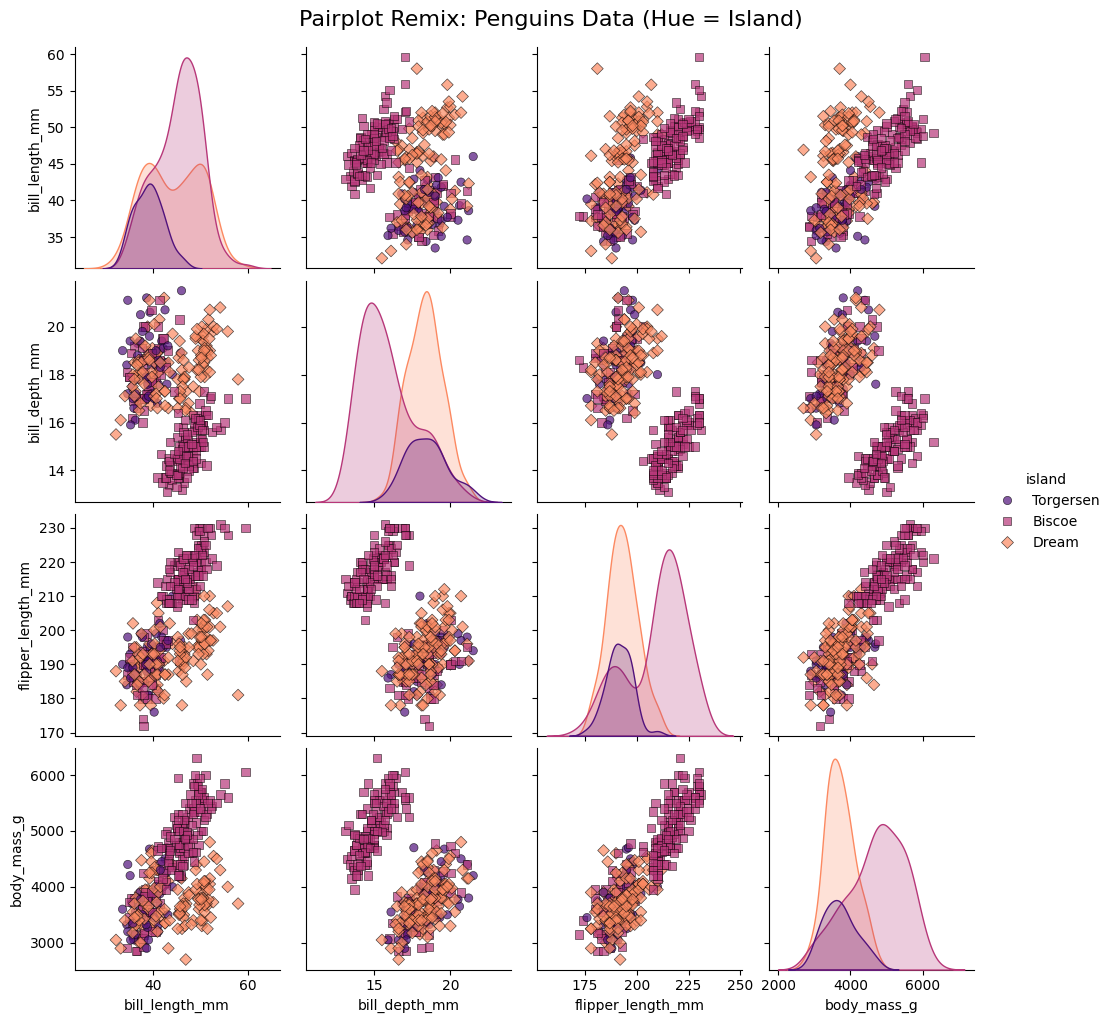

In [9]:
# --- Task 4: Pairplot Remix ---
penguins = sns.load_dataset("penguins")

penguins_clean = penguins.dropna(subset=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "sex", "island"])

sns.pairplot(
    data=penguins_clean,
    hue="island",
    diag_kind="kde",
    markers=["o", "s", "D"],
    palette="magma",
    plot_kws={"alpha": 0.7, "edgecolor": "black"}
)

plt.suptitle("Pairplot Remix: Penguins Data (Hue = Island)", fontsize=16, y=1.02)
plt.show()


# Bar Graph on Pengiun Dataset (bad!!!)

In [ ]:
# Bar plot of species vs average body mass
#sns.barplot(x="species", y="body_mass_g", data=penguins)

plt.bar(penguins['species'], penguins['body_mass_g'])
# Add title and labels
plt.title('Average Body Mass for Each Penguin Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')

# Show the plot
plt.show()

# Corrected Bar Graph using aggreation

What is Aggregation?
Aggregation is the process of summarizing or combining data by performing calculations like mean, sum, count, median, etc. on groups within a dataset. This helps to simplify large datasets and extract meaningful insights.

In [ ]:
# creating panda series which consist of index and value.. example are bellow
# Calculate the mean body mass for each species
species_means = penguins.groupby('species')['body_mass_g'].mean()

# Plot using plt.bar (now using aggregated data)
plt.bar(species_means.index, species_means.values)

# Add title and labels
plt.title('Average Body Mass for Each Penguin Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')

# Show the plot
plt.show()


### Explanation:
- The dataset is **grouped by species** using `.groupby('species')`.  
- Instead of plotting raw values, we compute the **mean (`.mean()`)** body mass for each species.  
- This prevents **misleading bar plots** by ensuring data is **properly summarized** before visualization.  

---

### Other Types of Aggregation  
Besides `mean()`, you can use:  
- **`sum()`** → Total body mass per species  
- **`count()`** → Number of penguins per species  
- **`median()`** → Middle value of body mass  
- **`max()` / `min()`** → Largest or smallest body mass  


In [ ]:
species_means = penguins.groupby('species')['body_mass_g'].mean()
plt.bar(species_means.index, species_means.values)
plt.title('Average Body Mass for Each Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()


### Understanding `species_means`

`species_means` is a **Pandas Series** where:  
- The **index** contains **species names**: *(Adelie, Chinstrap, Gentoo)*.  
- The **values** contain the **mean body mass** for each species.  


In [ ]:
species_sum = penguins.groupby('species')['body_mass_g'].sum()
plt.bar(species_sum.index, species_sum.values)
plt.title('Sum of Body Mass for Each Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

### Aggregation with the Penguin Dataset

**Aggregation** is the process of summarizing data by grouping it and applying a function (e.g., mean, sum, min, max) to each group.

#### Example: Aggregating Body Mass by Species

If we want to summarize the **body mass** of penguins by their **species**, we can use pandas' `groupby()` function and apply aggregation functions like `mean`, `min`, and `max`.

#### Common Aggregations:

1. **Mean** (Average Body Mass by Species):
  


In [ ]:

   species_means = penguins.groupby('species')['body_mass_g'].mean()

Min (Smallest Body Mass by Species):

In [ ]:
species_min = penguins.groupby('species')['body_mass_g'].min()


Count (Number of Penguins by Species):
Sum ( Sum of Body mass for all penguins in each Species)

In [ ]:
species_count = penguins.groupby('species')['body_mass_g'].count()

species_sum = penguins.groupby('species')['body_mass_g'].sum()

In [ ]:
species_means.index


In [ ]:
species_means.values


### Using `groupby()` in pandas

When you use the `groupby()` function in pandas, the result is a **pandas Series or DataFrame** where the **index** corresponds to the grouping variable (in this case, `species`), and the **values** correspond to the aggregated quantity (like `mean`, `min`, `max`, etc.).




## Using Seaborn

One of the benefit of using seaborn is that automatically do agression for you.

In [ ]:
# Bar plot of species vs average body mass
sns.barplot(x="species", y="body_mass_g", data=penguins)

#plt.bar(penguins['species'], penguins['body_mass_g'])
# Add title and labels
plt.title('Average Body Mass for Each Penguin Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')

# Show the plot
plt.show()

In [ ]:

sns.barplot(x="species", y="body_mass_g", data=penguins, estimator=np.median)

plt.title('Median Body Mass for Each Penguin Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()


# Combined Bar Graph


In [ ]:

# Grouped bar plot: species vs body mass, colored by sex
sns.barplot(x='species', y='body_mass_g', hue='sex', data=penguins)

# Add title and labels
plt.title('Average Body Mass by Species and Sex')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')

# Show the plot
plt.show()


In [ ]:

# Grouped bar plot: species vs body mass, colored by sex
sns.barplot(x='species', y='body_mass_g', hue='island', data=penguins)

# Add title and labels
plt.title('Average Body Mass by Species and Sex')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

In [ ]:

# Grouped bar plot: species vs body mass, colored by sex
sns.barplot(x='sex', y='body_mass_g', hue='species', data=penguins)

# Add title and labels
plt.title('Average Body Mass by Species and Sex')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

In [ ]:

# Prepare data for stacking
species_sex_grouped = penguins.groupby(['species', 'sex'])['body_mass_g'].mean().unstack()

# Plot stacked bar graph
species_sex_grouped.plot(kind='bar', stacked=True)

# Add title and labels
plt.title('Stacked Bar Plot: Average Body Mass by Species and Sex')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')

# Show the plot
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# Bar plot for body mass by species
sns.barplot(x='species', y='body_mass_g', data=penguins, ax=axes[0])


# Bar plot for flipper length by species
sns.barplot(x='species', y='flipper_length_mm', data=penguins, ax=axes[1])

plt.bar(penguins['species'], penguins['body_mass_g'],ax=axes[2])


# Show the plot
plt.show()
# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()


# Task 5: Create a 2×2 Grid with Mixed Plot Types

Make a figure with **four subplots** arranged in a 2×2 grid using  
`fig, axes = plt.subplots(2, 2, figsize=(10, 8))`.

Use the **penguins dataset** and include a mix of plot types:

- **(Top-left)**: `sns.barplot()` → show **body mass by species**.  
- **(Top-right)**: `sns.scatterplot()` → plot **bill length vs bill depth**, color by `species`.  
- **(Bottom-left)**: `sns.histplot()` → distribution of **flipper length**, separated by `species` (`hue="species"`).  
- **(Bottom-right)**: `sns.boxplot()` → compare **body mass by island**.  

Add a **title for each subplot**, and call `plt.tight_layout()` at the end.

**Deliverable:** one combined figure (saved as `.png`, around 150 dpi) that clearly shows all four plots with appropriate labels and colors.


/tmp/ipython-input-2172382050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-2172382050.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


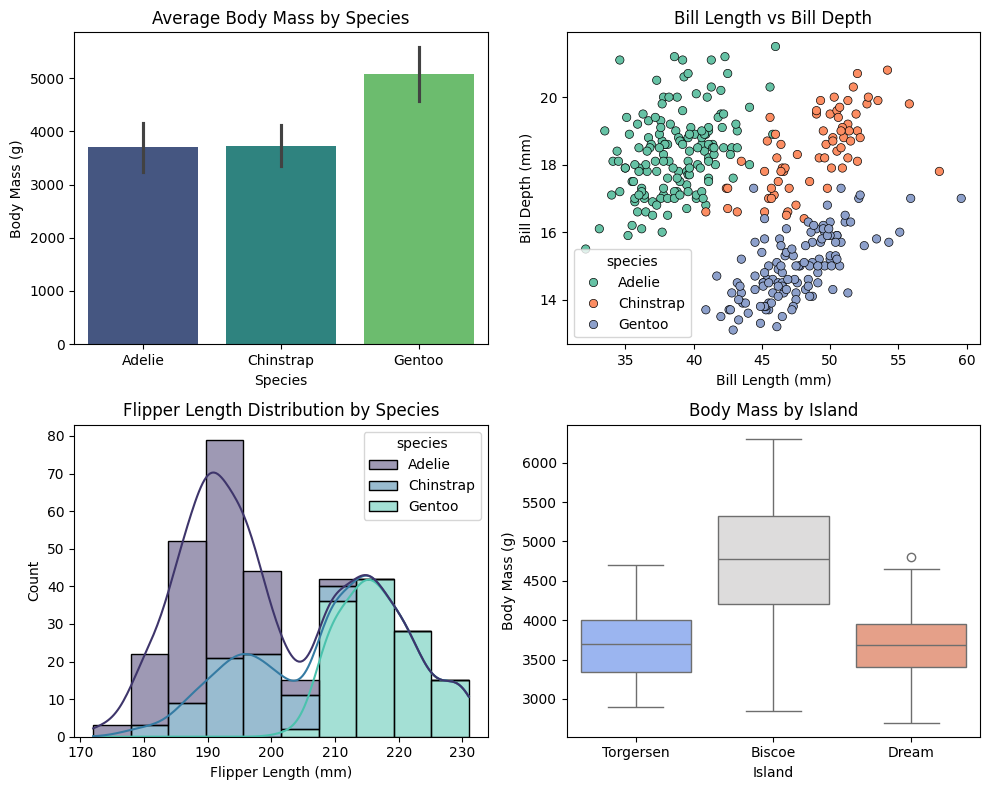

In [10]:
# --- Task 5: Create a 2×2 Grid with Mixed Plot Types ---
penguins = sns.load_dataset("penguins")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.barplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    palette="viridis",
    ax=axes[0, 0],
    errorbar="sd"
)
axes[0, 0].set_title("Average Body Mass by Species")
axes[0, 0].set_xlabel("Species")
axes[0, 0].set_ylabel("Body Mass (g)")

sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette="Set2",
    ax=axes[0, 1],
    edgecolor="black"
)
axes[0, 1].set_title("Bill Length vs Bill Depth")
axes[0, 1].set_xlabel("Bill Length (mm)")
axes[0, 1].set_ylabel("Bill Depth (mm)")

sns.histplot(
    data=penguins,
    x="flipper_length_mm",
    hue="species",
    kde=True,
    multiple="stack",
    palette="mako",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Flipper Length Distribution by Species")
axes[1, 0].set_xlabel("Flipper Length (mm)")
axes[1, 0].set_ylabel("Count")

sns.boxplot(
    data=penguins,
    x="island",
    y="body_mass_g",
    palette="coolwarm",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Body Mass by Island")
axes[1, 1].set_xlabel("Island")
axes[1, 1].set_ylabel("Body Mass (g)")

plt.tight_layout()

plt.savefig("penguins_4in1_dashboard.png", dpi=150)

plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# Bar plot for body mass by species
sns.barplot(x='species', y='body_mass_g', data=penguins, ax=axes[0])


# Bar plot for flipper length by species
sns.barplot(x='species', y='flipper_length_mm', data=penguins, ax=axes[1])

# Use axes[2].bar() instead of plt.bar() to explicitly specify the subplot
axes[2].bar(penguins['species'], penguins['body_mass_g']) # Changed this line to use axes[2].bar()


# Show the plot
plt.show()
# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

# Simple Exam of Pie Graph

In [ ]:
# Example pie chart
labels = ['A', 'B', 'C']
sizes = [50, 25, 25]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.show()

In [ ]:


# Count the number of penguins in each species
species_counts = penguins['species'].value_counts()

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(species_counts, labels=species_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'coral'])
plt.title('Penguin Species Distribution')

# Show the plot
plt.show()


The `autopct='%1.1f%%'` parameter in the `plt.pie()` function is used to **display the percentage value** on each segment of the pie chart.

### Explanation:
- **`'%1.1f%%'`** is a string format for **floating point numbers**.
  - **`1.1f`** means:
    - **1**: The total number of digits to display before the decimal point (which is the minimum, but if there are more digits, they'll be displayed).
    - **1**: The number of digits to display **after** the decimal point.
    - **f**: This specifies that the value should be displayed as a floating point number.
  - The **`%%`** is used to display the percentage symbol (`%`).

### Breakdown:
- **`1.1f`**: Displays the number as a float with one digit after the decimal point.
- **`%%`**: Adds the literal percentage sign after the number.

### Example:
If you have a pie chart slice that represents 33.33% of the data:
- **`autopct='%1.1f%%'`** will display `33.3%` (rounding to one decimal place).
- **`autopct='%1.0f%%'`** will display `33%` (no decimal places).
- **`autopct='%1.2f%%'`** will display `33.33%` (two decimal places).



In [ ]:
# Example pie chart
explode = (0.1,0, 0)
labels = ['A', 'B', 'C']
sizes = [50, 25, 25]
plt.pie(sizes, labels=labels,explode=explode, hatch=['**O', 'oO', 'O.O', '.||.'])
plt.show()


In [ ]:
explode = (0, 0.1, 0, 0)  # only "explode" the 2nd slice (i.e. 'Hogs')

fig, ax = plt.subplots()
ax.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
       shadow=True, startangle=90)
plt.show()

# Task 6: Create a Pie Chart (Penguins Dataset)

3. Count how many penguins belong to each species using `value_counts()`.  
4. Create a pie chart using `plt.pie()` with:
   - `labels` as species names.  
   - `autopct='%1.1f%%'` to show percentages.  
   - `startangle=90` for better orientation.  
   - `explode` to slightly separate one slice (optional).  
5. Add a **title** like `"Distribution of Penguin Species"`.  
6. Make the chart circular by setting `plt.axis('equal')`.  



species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


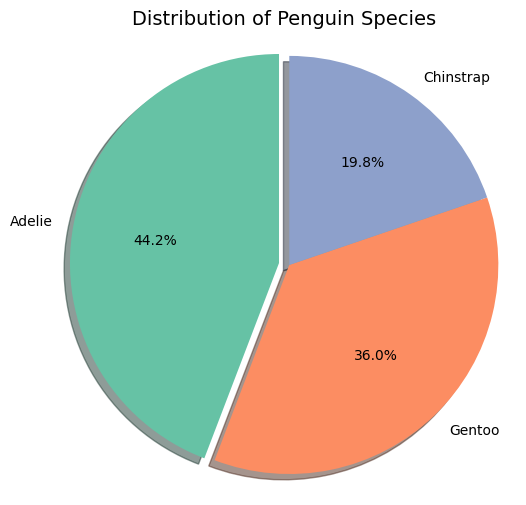

In [11]:
# --- Task 6: Create a Pie Chart (Penguins Dataset) ---
penguins = sns.load_dataset("penguins")

species_counts = penguins["species"].value_counts()
print(species_counts)

labels = species_counts.index
sizes = species_counts.values

explode = [0.05, 0, 0]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    colors=plt.cm.Set2.colors
)

plt.axis('equal')

plt.title("Distribution of Penguin Species", fontsize=14)

plt.show()


### 🏷️ K-Means Clustering on the Penguins Dataset

K-Means clustering is an **unsupervised learning algorithm** used to **group similar data points** into clusters. In this example, we apply K-Means to the **Palmer Penguins dataset** to categorize penguins based on their **bill length, bill depth, flipper length, and body mass**.

### 🔹 Steps Involved:
1. **Preprocessing**:  
   - Missing values are removed to ensure clean data.  
   - Only **numerical features** (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) are selected.  

2. **Standardization**:  
   - The features are standardized using `StandardScaler()` to normalize the scale of measurements, improving clustering accuracy.  

3. **Applying K-Means**:  
   - The dataset is clustered into **3 groups (`n_clusters=3`)**, aligning with the three penguin species.  
   - The `fit_predict()` method assigns each penguin to a cluster.  

4. **Visualization**:  
   - A **scatter plot** is created using `bill_length_mm` and `flipper_length_mm` as axes.  
   - Each point is colored based on its assigned **cluster** using the `viridis` colormap.  



In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Preprocessing: Drop rows with missing values
penguins_clean = penguins.dropna()

# Select numerical features for clustering
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Standardize the data
scaler = StandardScaler()
penguins_scaled = scaler.fit_transform(penguins_clean[features])

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
penguins_clean['cluster'] = kmeans.fit_predict(penguins_scaled)

# Visualize the clusters using bill length and flipper length
plt.scatter(penguins_clean['bill_length_mm'], penguins_clean['flipper_length_mm'], c=penguins_clean['cluster'], cmap='viridis')

# Add labels and title
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.title('K-Means Clustering of Penguins')

plt.show()
